# Sentiment Analysis on Movie Reviews

In [6]:
!pip install keras-tuner
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
import torch
import keras_tuner as kt
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, Bidirectional, LSTM, Dense, Dropout, GlobalMaxPooling1D
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)
from tensorflow.keras.layers import SpatialDropout1D
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 4.1 MB/s eta 0:00:00


In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Loading the Dataset

In [8]:
raw_reviews_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/CS-171/IMDB Dataset.csv")
raw_reviews_df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


## Exploratory Data Analysis

  sentiment  count
0  positive  25000
1  negative  25000


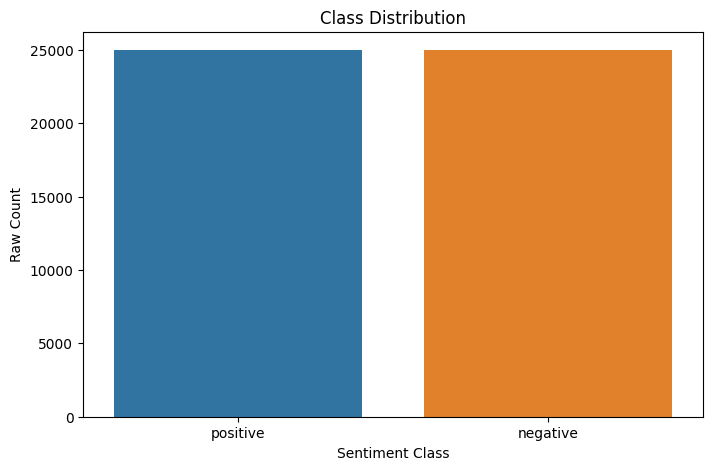

In [9]:
# Class Distributions
class_distributions = raw_reviews_df['sentiment'].value_counts().reset_index()
print(class_distributions)

plt.figure(figsize=(8, 5))
sns.barplot(data=class_distributions,
            x='sentiment',
            y='count',
            hue='sentiment')

plt.title("Class Distribution")
plt.xlabel("Sentiment Class")
plt.ylabel("Raw Count")
plt.show()

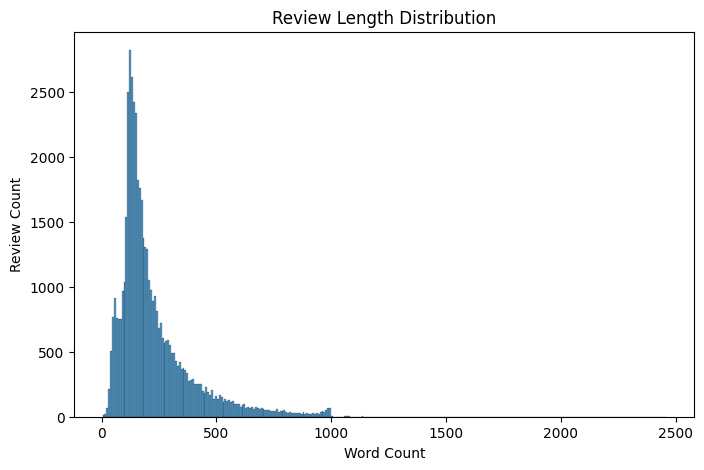

In [10]:
# Sequence Length

# The replace function was added to deal with the line break tags seen in the data preview above
sequence_word_length = raw_reviews_df['review'].str.replace('<br />', ' ', regex=False).str.split().str.len()

plt.figure(figsize=(8, 5))
sns.histplot(sequence_word_length)

plt.title("Review Length Distribution")
plt.xlabel("Word Count")
plt.ylabel("Review Count")
plt.show()

## Data Preprocessing

In [11]:
# Basic Cleaning (removing <br /> tags again)
raw_reviews_df['cleaned_review'] = raw_reviews_df['review'].str.replace('<br />', ' ', regex=False)

# Split into Train and Test sets
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    raw_reviews_df['cleaned_review'],
    raw_reviews_df['sentiment'].map({'positive': 1, 'negative': 0}),
    test_size=0.1,
    random_state=42
)

# Keras Tokenization
unique_words_count = len(set(raw_reviews_df['cleaned_review'].str.lower().str.split().explode()))
print(f"Total unique words in dataset: {unique_words_count}")

VOCAB_SIZE = 10000 # How many of the most frequent unique words we keep (TO DO: try other values for this)

percentile_70 = sequence_word_length.quantile(0.70) # We want to preseverve most our data, so our max_len is based on percentile
print(f"The 70th percentile of review lengths is: {percentile_70} words.")

MAX_LEN = int(percentile_70) # Max token length of each review

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train_raw)

# Transform and Pad
X_train = pad_sequences(tokenizer.texts_to_sequences(X_train_raw), maxlen=MAX_LEN, padding='post')
X_test = pad_sequences(tokenizer.texts_to_sequences(X_test_raw), maxlen=MAX_LEN, padding='post')

BATCH_SIZE = 64
# Batching
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test))

train_dataset = train_dataset.shuffle(buffer_size=10000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print(f"Datasets created with batch size: {BATCH_SIZE}")

Total unique words in dataset: 365437
The 70th percentile of review lengths is: 245.0 words.
Datasets created with batch size: 64


## Define BiLSTM and LSTM architecture

In [12]:
def build_model_fn(model_type):
    def build_model(hp):
        model = Sequential()

        param_grid = {
            'embed_dim':    hp.Choice('embed_dim', [64]),
            'spatial_drop': hp.Choice('spatial_drop', [0.2]),
            'units_1':      hp.Choice('units_1', [64, 128]),
            'units_2':      hp.Choice('units_2', [32, 64]),
            'dropout_rate': hp.Choice('dropout_rate', [0.2, 0.3]),
        }

        model.add(Embedding(VOCAB_SIZE, param_grid['embed_dim'], name='embedding'))
        model.add(SpatialDropout1D(param_grid['spatial_drop']))

        if model_type == 'BiLSTM':
            model.add(Bidirectional(LSTM(param_grid['units_1'], return_sequences=True)))
            model.add(Dropout(param_grid['dropout_rate']))
            model.add(Bidirectional(LSTM(param_grid['units_2'], return_sequences=False)))

        elif model_type == 'LSTM':
            model.add(LSTM(param_grid['units_1'], return_sequences=True))
            model.add(Dropout(param_grid['dropout_rate']))
            model.add(LSTM(param_grid['units_2'], return_sequences=False))

        model.add(Dropout(param_grid['dropout_rate']))
        model.add(Dense(1, activation='sigmoid'))
        model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
        return model

    return build_model


def train_models(model_type='BiLSTM'):
    tuner = kt.GridSearch(
        build_model_fn(model_type),
        objective='val_loss',
        max_trials=20,
        directory='tuner_results',
        project_name=model_type,
        overwrite=True,
    )

    tuner.search(
        train_dataset,
        validation_data=test_dataset,
        epochs=50,
        callbacks=[
            EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1),
        ]
    )

    best_model = tuner.get_best_models(num_models=1)[0]
    best_params = tuner.get_best_hyperparameters(num_trials=1)[0].values
    best_score = tuner.oracle.get_best_trials(1)[0].metrics.get_last_value('val_loss')

    history = best_model.fit(
        train_dataset,
        validation_data=test_dataset,
        epochs=50,
        callbacks=[
            EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1),
        ]
    )

    return best_model, history, best_score, best_params, X_test, y_test

In [13]:
def model_evaluation(model, history, best_score, best_params, X_test, y_test):
    y_prob = model.predict(X_test, batch_size=32, verbose=0).flatten()
    y_pred = (y_prob >= 0.5).astype(int)

    # Compute metrics
    accuracy  = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall    = recall_score(y_test, y_pred)
    f1        = f1_score(y_test, y_pred)
    auc       = roc_auc_score(y_test, y_prob)

    print(f'Best Val Loss : {best_score:.4f}')  # new
    print(f'Best Params   : {best_params}')     # new
    print()
    print(f'Accuracy  : {accuracy:.4f}')
    print(f'Precision : {precision:.4f}')
    print(f'Recall    : {recall:.4f}')
    print(f'F1        : {f1:.4f}')
    print(f'AUC-ROC   : {auc:.4f}')
    print()
    print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # --- Confusion matrix ---
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    axes[0].set_title('Confusion Matrix')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Actual')

    # --- Training vs validation loss ---
    axes[1].plot(history.history['loss'],     label='Train Loss')
    axes[1].plot(history.history['val_loss'], label='Val Loss', ls='--')
    axes[1].set_title('Training vs Validation Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    # --- ROC curve ---
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    axes[2].plot(fpr, tpr, lw=2, label=f'AUC = {auc:.4f}')
    axes[2].plot([0, 1], [0, 1], 'k--', lw=1)
    axes[2].set_title('ROC Curve')
    axes[2].set_xlabel('False Positive Rate')
    axes[2].set_ylabel('True Positive Rate')
    axes[2].legend()
    axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    return [accuracy, precision, recall, f1, auc]

## Model training

In [14]:
BiLSTM, BiLSTM_history, BiLSTM_score, BiLSTM_params, X_test, y_test = train_models('BiLSTM')

Trial 8 Complete [00h 04m 40s]
val_loss: 0.25782930850982666

Best val_loss So Far: 0.253517210483551
Total elapsed time: 00h 30m 21s
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 32 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


704/704 ━━━━━━━━━━━━━━━━━━━━ 32s 40ms/step - accuracy: 0.9027 - loss: 0.2514 - val_accuracy: 0.8252 - val_loss: 0.4933 - learning_rate: 0.0010
Epoch 2/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 39ms/step - accuracy: 0.9210 - loss: 0.2107 - val_accuracy: 0.8946 - val_loss: 0.2763 - learning_rate: 0.0010
Epoch 3/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 39ms/step - accuracy: 0.9405 - loss: 0.1663 - val_accuracy: 0.8948 - val_loss: 0.2697 - learning_rate: 0.0010
Epoch 4/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 40ms/step - accuracy: 0.9530 - loss: 0.1353 - val_accuracy: 0.8958 - val_loss: 0.2871 - learning_rate: 0.0010
Epoch 5/50
703/704 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9576 - loss: 0.1216
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 39ms/step - accuracy: 0.9570 - loss: 0.1233 - val_accuracy: 0.8964 - val_loss: 0.3100 - learning_rate: 0.0010
Epoch 6/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 39ms/step - accuracy: 0.9707 - loss: 0.0928 -

Best Val Loss : 0.2535
Best Params   : {'embed_dim': 64, 'spatial_drop': 0.2, 'units_1': 64, 'units_2': 32, 'dropout_rate': 0.2}

Accuracy  : 0.8948
Precision : 0.8894
Recall    : 0.9035
F1        : 0.8964
AUC-ROC   : 0.9592

              precision    recall  f1-score   support

    Negative       0.90      0.89      0.89      2481
    Positive       0.89      0.90      0.90      2519

    accuracy                           0.89      5000
   macro avg       0.89      0.89      0.89      5000
weighted avg       0.89      0.89      0.89      5000



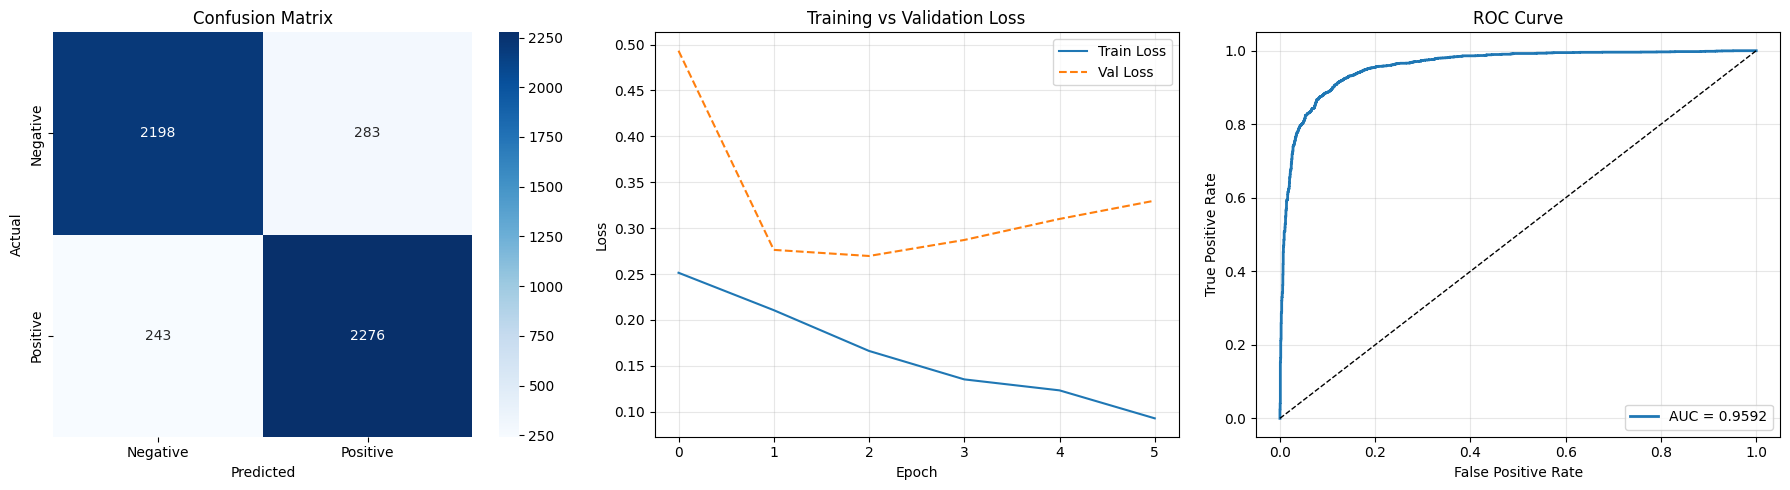

In [15]:
BiLSTM_eval = model_evaluation(BiLSTM, BiLSTM_history, BiLSTM_score, BiLSTM_params, X_test, y_test)

In [17]:
LSTM, LSTM_history, LSTM_score, LSTM_params, X_test, y_test = train_models('LSTM')

Trial 8 Complete [00h 02m 38s]
val_loss: 0.25950726866722107

Best val_loss So Far: 0.2404661327600479
Total elapsed time: 00h 22m 03s
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 20 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 22ms/step - accuracy: 0.9345 - loss: 0.1814 - val_accuracy: 0.9012 - val_loss: 0.2432 - learning_rate: 0.0010
Epoch 2/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - accuracy: 0.9476 - loss: 0.1487 - val_accuracy: 0.8968 - val_loss: 0.2881 - learning_rate: 0.0010
Epoch 3/50
703/704 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9600 - loss: 0.1202
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - accuracy: 0.9616 - loss: 0.1168 - val_accuracy: 0.9006 - val_loss: 0.3393 - learning_rate: 0.0010
Epoch 4/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - accuracy: 0.9772 - loss: 0.0789 - val_accuracy: 0.8950 - val_loss: 0.3259 - learning_rate: 5.0000e-04
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.


Best Val Loss : 0.2405
Best Params   : {'embed_dim': 64, 'spatial_drop': 0.2, 'units_1': 128, 'units_2': 64, 'dropout_rate': 0.2}

Accuracy  : 0.9012
Precision : 0.8887
Recall    : 0.9190
F1        : 0.9036
AUC-ROC   : 0.9673

              precision    recall  f1-score   support

    Negative       0.91      0.88      0.90      2481
    Positive       0.89      0.92      0.90      2519

    accuracy                           0.90      5000
   macro avg       0.90      0.90      0.90      5000
weighted avg       0.90      0.90      0.90      5000



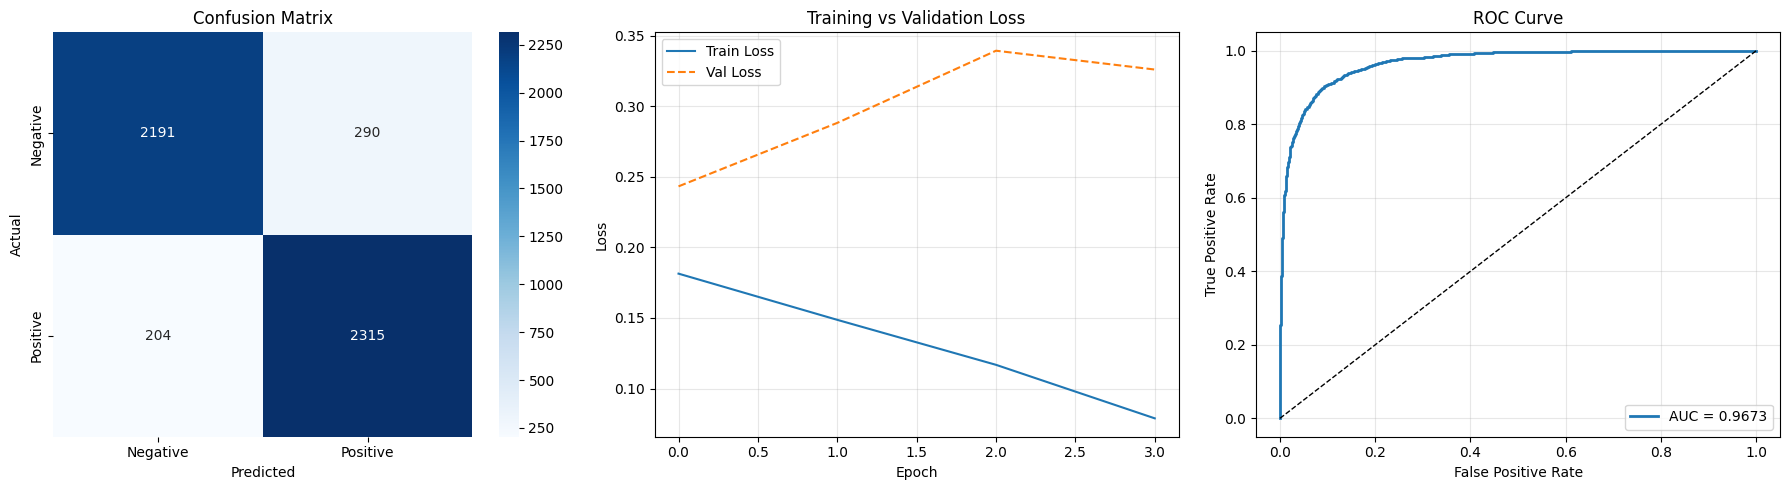

In [18]:
LSTM_eval = model_evaluation(LSTM, LSTM_history, LSTM_score, LSTM_params, X_test, y_test)

## Use distilBERT(pretrained model) on test data

In [19]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MODEL_NAME = "distilbert-base-uncased-finetuned-sst-2-english"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

distilbert_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [20]:
def evaluate_distilbert(model, tokenizer, X_test_raw, y_test, max_length=256, batch_size=32):
    model.eval()

    y_prob = []

    # Batch inference
    for i in range(0, len(X_test_raw), batch_size):

        batch_texts = X_test_raw[i:i+batch_size]

        encodings = tokenizer(
            batch_texts,
            truncation=True,
            padding=True,
            max_length=max_length,
            return_tensors="pt"
        )

        with torch.no_grad():
            outputs = model(
                input_ids=encodings["input_ids"],
                attention_mask=encodings["attention_mask"]
            )

        probs = torch.softmax(outputs.logits, dim=1)[:, 1]

        y_prob.extend(probs.cpu().numpy())

        del encodings, outputs, probs
        torch.cuda.empty_cache() if torch.cuda.is_available() else None

    y_prob = np.array(y_prob)

    # Predictions
    y_pred = (y_prob >= 0.5).astype(int)

    # Metrics
    accuracy  = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall    = recall_score(y_test, y_pred)
    f1        = f1_score(y_test, y_pred)
    auc       = roc_auc_score(y_test, y_prob)

    print(f'Accuracy  : {accuracy:.4f}')
    print(f'Precision : {precision:.4f}')
    print(f'Recall    : {recall:.4f}')
    print(f'F1        : {f1:.4f}')
    print(f'AUC-ROC   : {auc:.4f}')

    print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

    # Plots
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Negative','Positive'],
                yticklabels=['Negative','Positive'],
                ax=axes[0])

    axes[0].set_title("Confusion Matrix")

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    axes[1].plot(fpr, tpr, label=f"AUC={auc:.4f}")
    axes[1].plot([0,1],[0,1],'k--')
    axes[1].set_title("ROC Curve")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    return [accuracy, precision, recall, f1, auc]

Preprocess x_test_raw into usable state for distilbert model

In [21]:
X_test_raw = [str(x) for x in X_test_raw]

Accuracy  : 0.8758
Precision : 0.9025
Recall    : 0.8448
F1        : 0.8727
AUC-ROC   : 0.9500
              precision    recall  f1-score   support

    Negative       0.85      0.91      0.88      2481
    Positive       0.90      0.84      0.87      2519

    accuracy                           0.88      5000
   macro avg       0.88      0.88      0.88      5000
weighted avg       0.88      0.88      0.88      5000



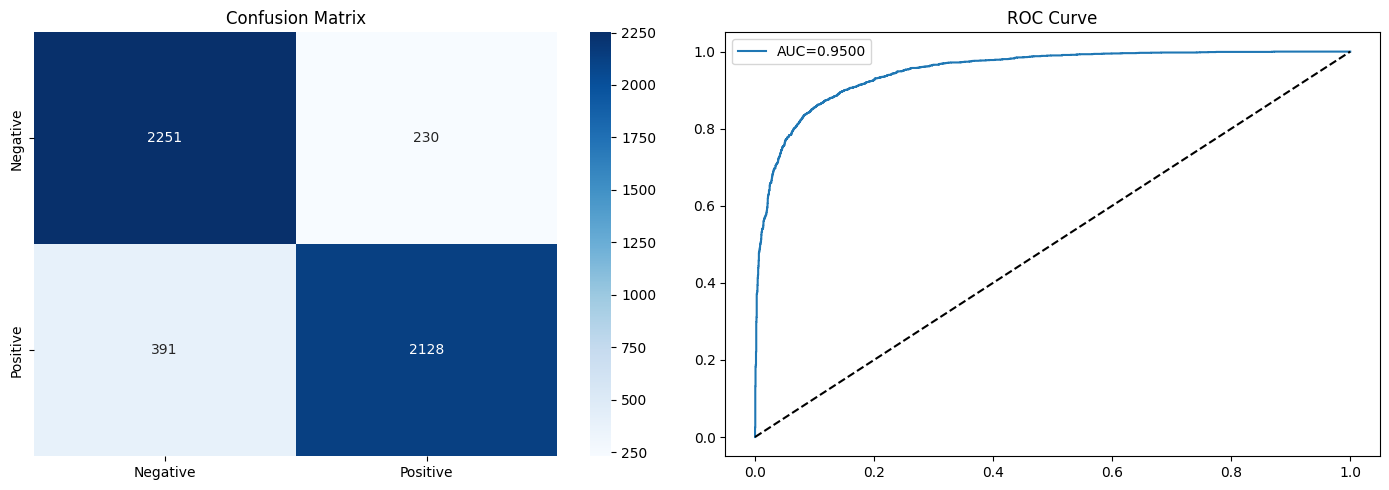

In [22]:
metrics_bert = evaluate_distilbert(
    model=distilbert_model,
    tokenizer=tokenizer,
    X_test_raw=X_test_raw,
    y_test=y_test
)

In [27]:
# DistilBERT parameter count
distilbert_params = sum(p.numel() for p in distilbert_model.parameters())
print(f'DistilBERT parameters : {distilbert_params:,}')

# custom model
custom_params_bilstm = BiLSTM.count_params()
print(f'Custom BiLSTM parameters : {custom_params_bilstm:,}')

custom_params_lstm = LSTM.count_params()
print(f'Custom LSTM parameters : {custom_params_lstm:,}')

DistilBERT parameters : 66,955,010
Custom BiLSTM parameters : 747,329
Custom LSTM parameters : 788,289


## Compare model results

In [24]:
def compare_models_table(BiLSTM_scores, LSTM_scores, BERT_scores):

    metrics = ["Accuracy", "Precision", "Recall", "F1", "AUC"]

    df = pd.DataFrame(
        [
            BiLSTM_scores,
            LSTM_scores,
            BERT_scores
        ],
        index=[
            "BiLSTM",
            "LSTM",
            "DistilBERT"
        ],
        columns=metrics
    )

    return df

In [26]:
compare_models_table(BiLSTM_eval, LSTM_eval, metrics_bert)

,Accuracy,Precision,Recall,F1,AUC
BiLSTM,0.8948,0.889410,0.903533,0.896416,0.959183
LSTM,0.9012,0.888676,0.919015,0.903591,0.967266
DistilBERT,0.8758,0.902460,0.844780,0.872668,0.949974


## Prediction example

In [44]:
def predict_example(model, tokenizer, text, model_type='keras'):

    if model_type == 'keras':
        model_name = 'BiLSTM' if 'bidirectional' in [l.name for l in model.layers] else 'LSTM'
        sequence = tokenizer.texts_to_sequences([text])
        padded   = pad_sequences(sequence, maxlen=MAX_LEN)
        prob     = model.predict(padded, verbose=0)[0][0]

    elif model_type == 'distilbert':
        model_name = 'DistilBERT'
        inputs = tokenizer(text, return_tensors='pt', truncation=True, padding=True)
        with torch.no_grad():
            outputs = model(**inputs)
        prob = torch.softmax(outputs.logits, dim=1)[0][1].item()

    label = 'Positive' if prob >= 0.5 else 'Negative'

    print(f'Model      : {model_name}')
    print(f'Text       : {text}')
    print(f'Prediction : {label}')
    print(f'Confidence : {1 - prob:.4f}')
    print()

In [42]:
keras_tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
keras_tokenizer.fit_on_texts(X_train_raw)

X_train = pad_sequences(keras_tokenizer.texts_to_sequences(X_train_raw), maxlen=MAX_LEN, padding='post')
X_test  = pad_sequences(keras_tokenizer.texts_to_sequences(X_test_raw),  maxlen=MAX_LEN, padding='post')

In [45]:
my_text = "The film had great visuals but the story was a complete mess."

predict_example(model=BiLSTM,            tokenizer=keras_tokenizer, text=my_text, model_type='keras')
predict_example(model=LSTM,              tokenizer=keras_tokenizer, text=my_text, model_type='keras')
predict_example(model=distilbert_model,  tokenizer=tokenizer,       text=my_text, model_type='distilbert')

Model      : BiLSTM
Text       : The film had great visuals but the story was a complete mess.
Prediction : Negative
Confidence : 0.7717

Model      : LSTM
Text       : The film had great visuals but the story was a complete mess.
Prediction : Negative
Confidence : 0.9504

Model      : DistilBERT
Text       : The film had great visuals but the story was a complete mess.
Prediction : Negative
Confidence : 0.9996

